## **Applied Models :**

1. K-Means

2. DBSCAN

3. Mean-Shift


## **Importing**

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

## **Loading Data**

In [69]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/ColabNotebooks/PersonaCluster

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ColabNotebooks/PersonaCluster


In [70]:
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/PersonaCluster/input/data-final.csv', sep='\t')
df.head(5)

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


## **Dataset Overview**

In [71]:
df.shape

(1015341, 110)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Columns: 110 entries, EXT1 to long_appx_lots_of_err
dtypes: float64(104), int64(2), object(4)
memory usage: 852.1+ MB


In [73]:
df.columns

Index(['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9',
       'EXT10',
       ...
       'dateload', 'screenw', 'screenh', 'introelapse', 'testelapse',
       'endelapse', 'IPC', 'country', 'lat_appx_lots_of_err',
       'long_appx_lots_of_err'],
      dtype='object', length=110)

## **Select Personality Columns**

In [74]:
# Select personality questions
EXT = [f"EXT{i}" for i in range(1, 11)]
EST = [f"EST{i}" for i in range(1, 11)]
AGR = [f"AGR{i}" for i in range(1, 11)]
CSN = [f"CSN{i}" for i in range(1, 11)]
OPN = [f"OPN{i}" for i in range(1, 11)]
personality_cols = EXT + EST + AGR + CSN + OPN

data = df[personality_cols].copy()

## **Exploratory Data Analysis (EDA)**

In [75]:
print("Dataset Shape:")
data.shape

Dataset Shape:


(1015341, 50)

In [76]:
data.describe()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
count,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,...,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06
mean,2.648067e+00,2.773115e+00,3.288349e+00,3.140595e+00,3.276960e+00,2.401100e+00,2.771744e+00,3.414818e+00,2.963740e+00,3.556469e+00,...,3.654636e+00,2.075933e+00,4.000068e+00,1.999891e+00,3.792905e+00,1.894605e+00,3.976375e+00,3.182453e+00,4.122993e+00,3.958441e+00
std,1.264407e+00,1.323943e+00,1.215006e+00,1.237442e+00,1.277593e+00,1.225721e+00,1.400336e+00,1.271915e+00,1.346040e+00,1.305232e+00,...,1.157155e+00,1.112600e+00,1.097169e+00,1.090239e+00,9.923859e-01,1.104125e+00,1.008505e+00,1.255374e+00,1.041216e+00,1.034491e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,...,3.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,3.000000e+00,2.000000e+00,4.000000e+00,3.000000e+00
50%,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,4.000000e+00,...,4.000000e+00,2.000000e+00,4.000000e+00,2.000000e+00,4.000000e+00,2.000000e+00,4.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00
75%,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,5.000000e+00,...,5.000000e+00,3.000000e+00,5.000000e+00,3.000000e+00,5.000000e+00,2.000000e+00,5.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00


In [77]:
print("Dataset Columns Name:")
data.columns

Dataset Columns Name:


Index(['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9',
       'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8',
       'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7',
       'AGR8', 'AGR9', 'AGR10', 'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN6',
       'CSN7', 'CSN8', 'CSN9', 'CSN10', 'OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5',
       'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10'],
      dtype='object')

In [78]:
print("Missing Values:") # How many missing value?
data.isnull().sum()

Missing Values:


,0
EXT1,1783
EXT2,1783
EXT3,1783
EXT4,1783
EXT5,1783
EXT6,1783
EXT7,1783
EXT8,1783
EXT9,1783
EXT10,1783


In [79]:
data.info() # Show detaile columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Data columns (total 50 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   EXT1    1013558 non-null  float64
 1   EXT2    1013558 non-null  float64
 2   EXT3    1013558 non-null  float64
 3   EXT4    1013558 non-null  float64
 4   EXT5    1013558 non-null  float64
 5   EXT6    1013558 non-null  float64
 6   EXT7    1013558 non-null  float64
 7   EXT8    1013558 non-null  float64
 8   EXT9    1013558 non-null  float64
 9   EXT10   1013558 non-null  float64
 10  EST1    1013558 non-null  float64
 11  EST2    1013558 non-null  float64
 12  EST3    1013558 non-null  float64
 13  EST4    1013558 non-null  float64
 14  EST5    1013558 non-null  float64
 15  EST6    1013558 non-null  float64
 16  EST7    1013558 non-null  float64
 17  EST8    1013558 non-null  float64
 18  EST9    1013558 non-null  float64
 19  EST10   1013558 non-null  float64
 20  AGR1    1013558 non-null

In [80]:
for col in data.columns: #Column Information
    print(f"Column Name: {col}")
    print(f"Data Type: {data[col].dtype}")
    print(f"Unique Values: {data[col].nunique()}")
    print(f"Missing Values: {data[col].isnull().sum()}")
    print("-" * 40)

Column Name: EXT1
Data Type: float64
Unique Values: 6
Missing Values: 1783
----------------------------------------
Column Name: EXT2
Data Type: float64
Unique Values: 6
Missing Values: 1783
----------------------------------------
Column Name: EXT3
Data Type: float64
Unique Values: 6
Missing Values: 1783
----------------------------------------
Column Name: EXT4
Data Type: float64
Unique Values: 6
Missing Values: 1783
----------------------------------------
Column Name: EXT5
Data Type: float64
Unique Values: 6
Missing Values: 1783
----------------------------------------
Column Name: EXT6
Data Type: float64
Unique Values: 6
Missing Values: 1783
----------------------------------------
Column Name: EXT7
Data Type: float64
Unique Values: 6
Missing Values: 1783
----------------------------------------
Column Name: EXT8
Data Type: float64
Unique Values: 6
Missing Values: 1783
----------------------------------------
Column Name: EXT9
Data Type: float64
Unique Values: 6
Missing Values: 17

In [81]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
EXT1,1013558.0,2.648067,1.264407,0.0,1.0,3.0,4.0,5.0
EXT2,1013558.0,2.773115,1.323943,0.0,2.0,3.0,4.0,5.0
EXT3,1013558.0,3.288349,1.215006,0.0,2.0,3.0,4.0,5.0
EXT4,1013558.0,3.140595,1.237442,0.0,2.0,3.0,4.0,5.0
EXT5,1013558.0,3.276960,1.277593,0.0,2.0,3.0,4.0,5.0
EXT6,1013558.0,2.401100,1.225721,0.0,1.0,2.0,3.0,5.0
EXT7,1013558.0,2.771744,1.400336,0.0,2.0,3.0,4.0,5.0
EXT8,1013558.0,3.414818,1.271915,0.0,2.0,4.0,4.0,5.0
EXT9,1013558.0,2.963740,1.346040,0.0,2.0,3.0,4.0,5.0
EXT10,1013558.0,3.556469,1.305232,0.0,3.0,4.0,5.0,5.0


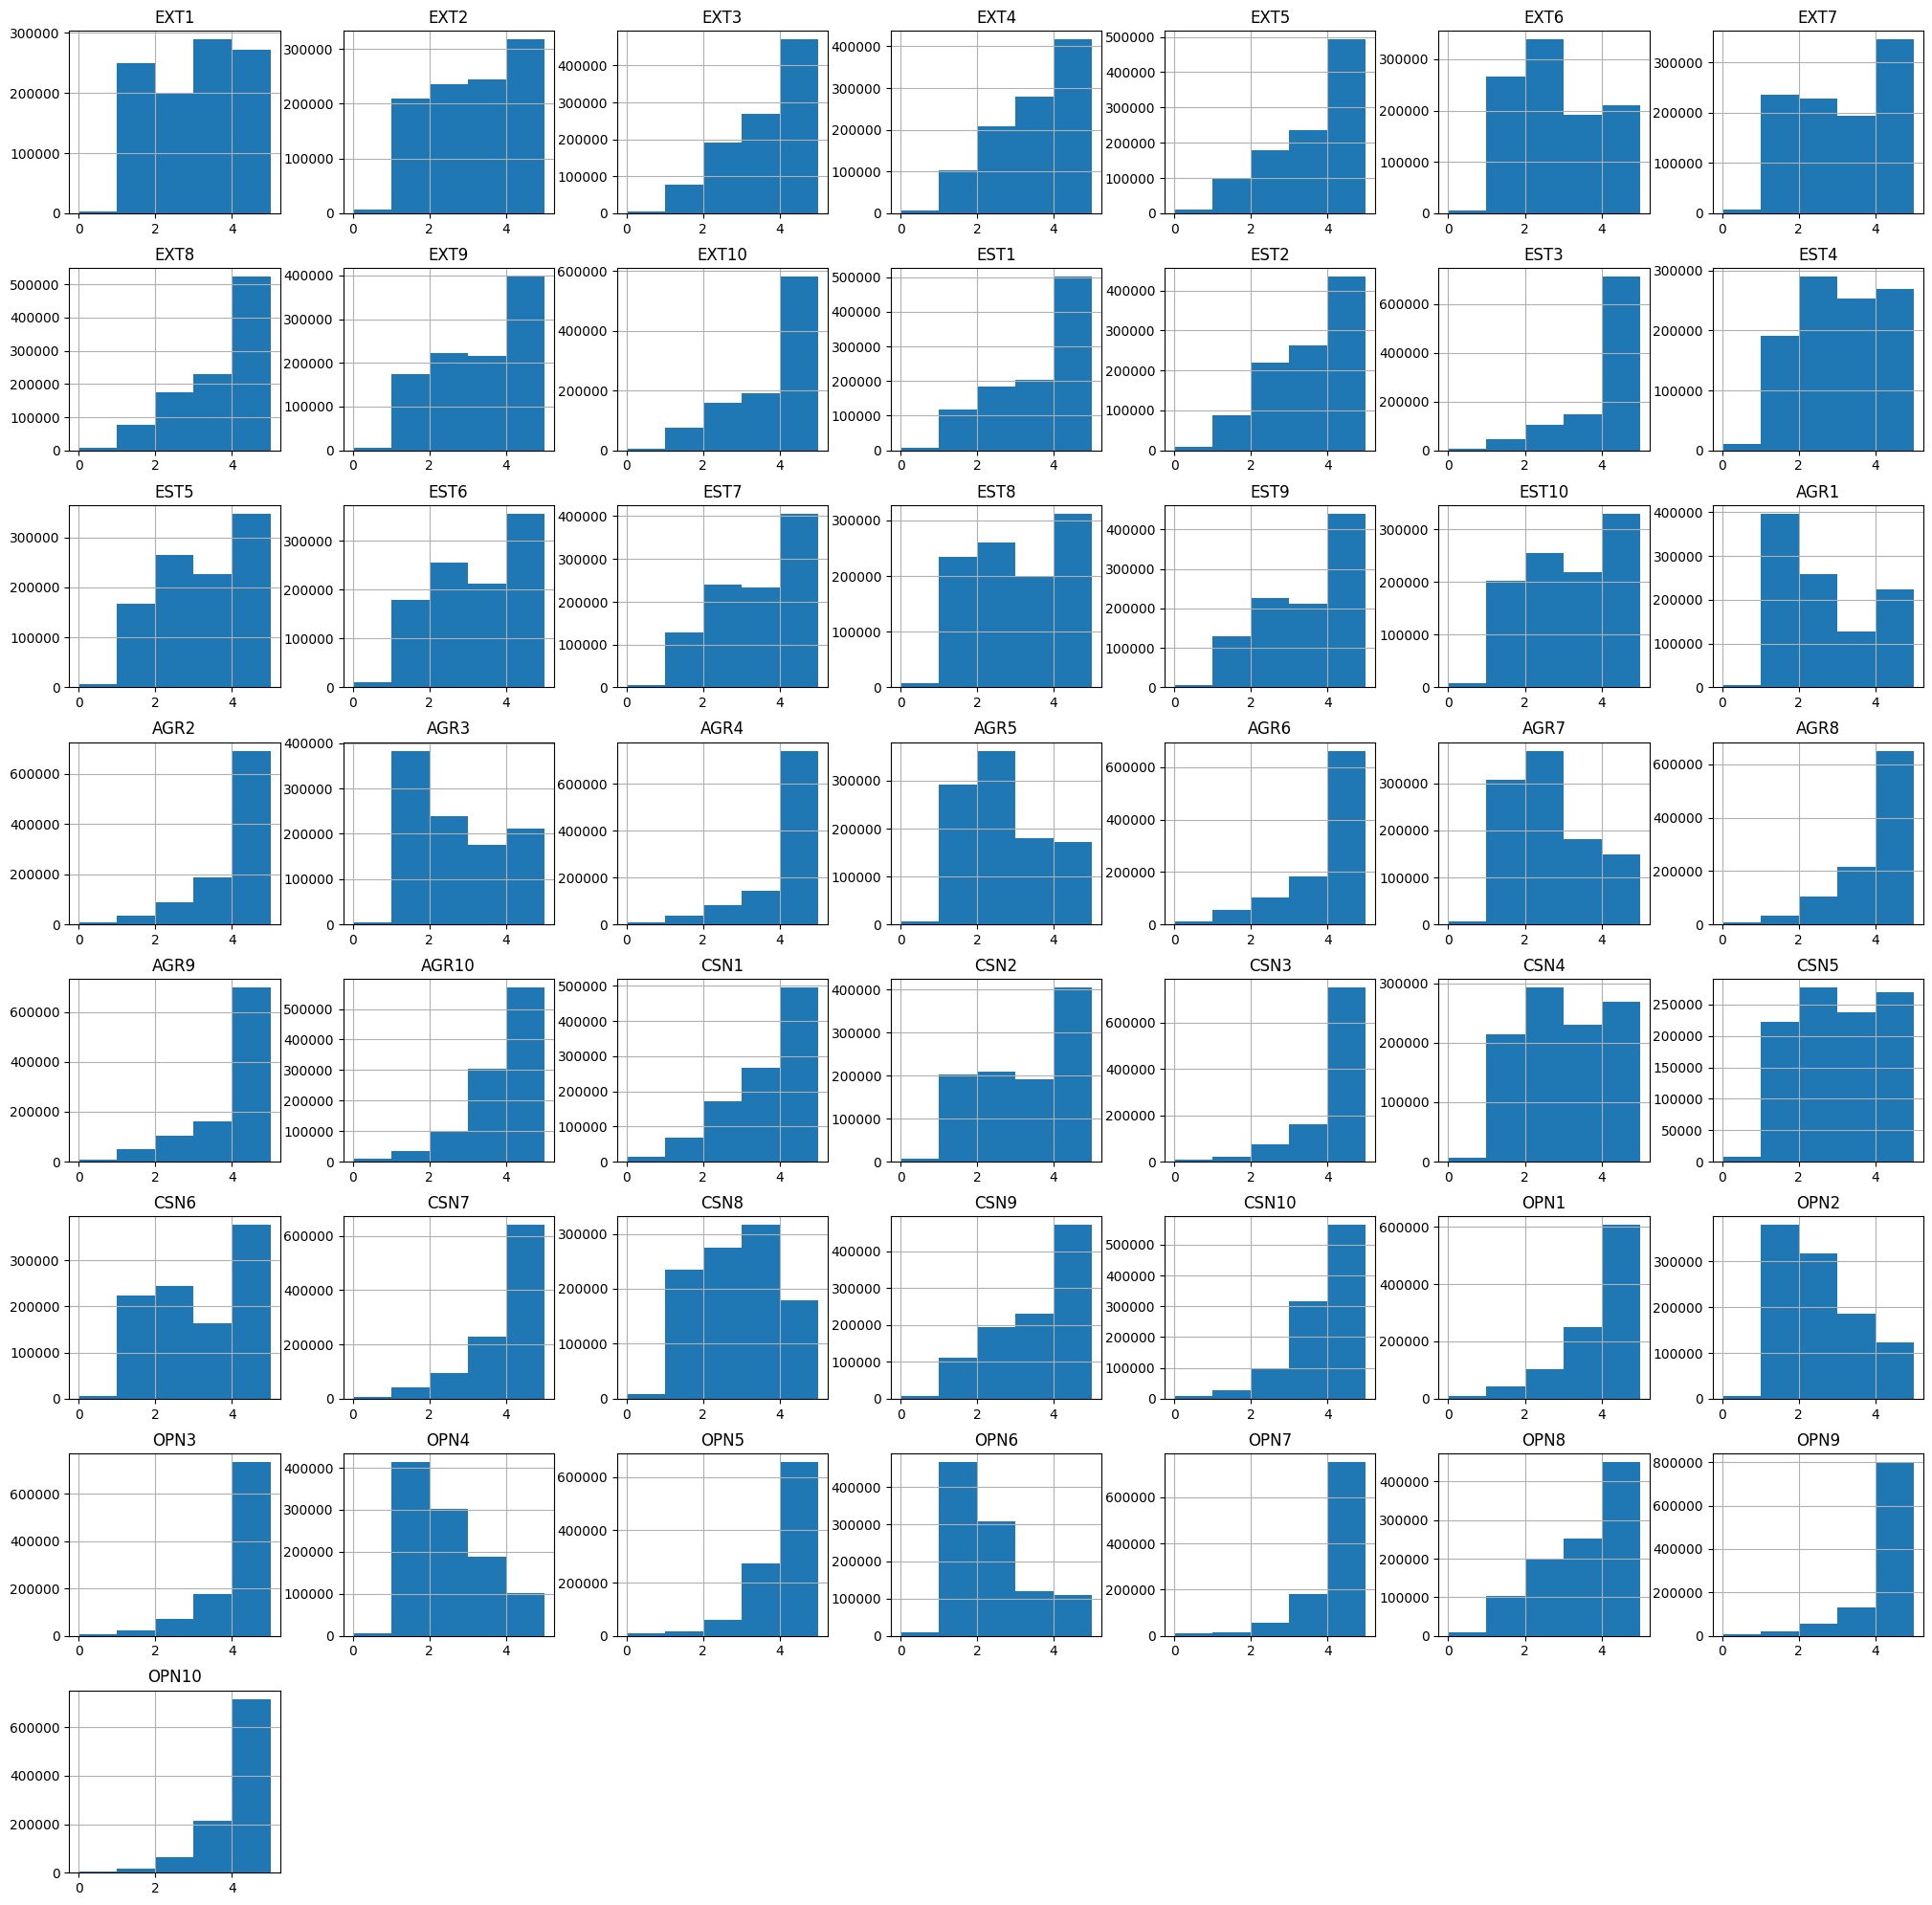

In [82]:
data.hist(figsize=(25,25), bins=5)
plt.show()

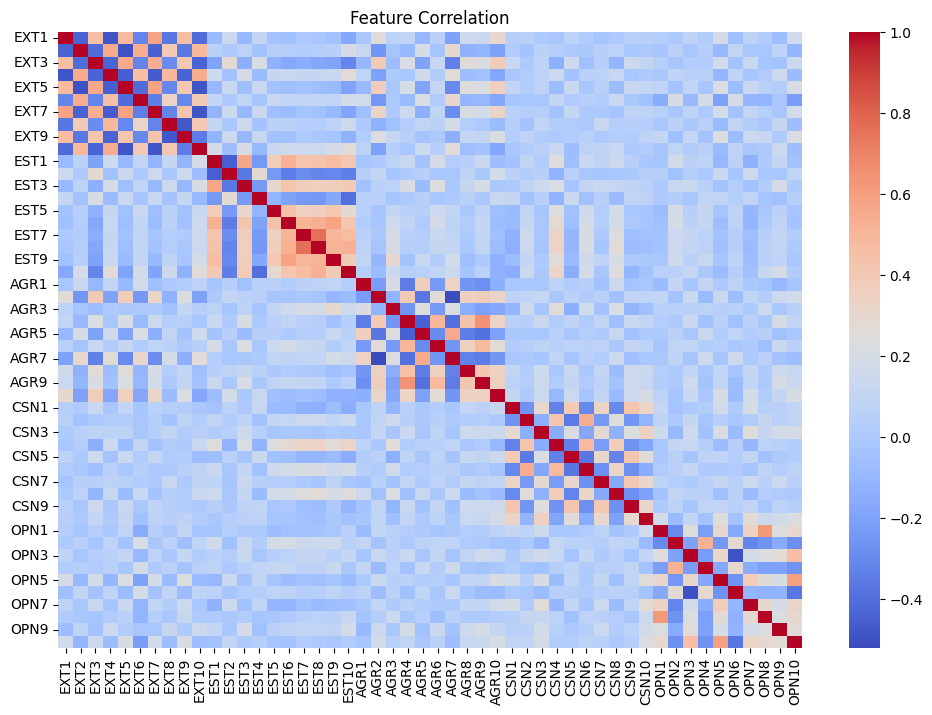

In [83]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation")
plt.show()

## **Data Cleaning**

**Convert Columns to Numeric**

In [84]:
# Convert all personality columns to numeric
data = data.apply(pd.to_numeric, errors="coerce")

**Remove Invalid Answers**

In [85]:
# Remove rows with missing or invalid answers
for col in personality_cols:
    data.loc[~data[col].between(1, 5), col] = np.nan

**Remove Rows with Missing Personality Answers**

In [86]:
data = data.dropna(subset=personality_cols)

**Response Time Cleaning**

In [87]:
time_cols = [col + "_E" for col in personality_cols if col + "_E" in df.columns]

print("Number of response time columns found:", len(time_cols))

if len(time_cols) > 0:

    time_data = df.loc[data.index, time_cols].copy()
    time_data = time_data.apply(pd.to_numeric, errors="coerce")

    # Remove impossible times
    time_data = time_data.replace([np.inf, -np.inf], np.nan)
    time_data[time_data <= 0] = np.nan

    # Average response time for each participant
    data["avg_response_time"] = time_data.mean(axis=1)

    before_time_cleaning = data.shape[0]

    # Remove very fast responses
    data = data[data["avg_response_time"] >= 300]

    # Remove extreme response times using IQR
    Q1 = data["avg_response_time"].quantile(0.25)
    Q3 = data["avg_response_time"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data = data[
        (data["avg_response_time"] >= lower_bound) &
        (data["avg_response_time"] <= upper_bound)
    ]

    after_time_cleaning = data.shape[0]

    print("Rows before response time cleaning:", before_time_cleaning)
    print("Rows after response time cleaning:", after_time_cleaning)
    print("Removed rows:", before_time_cleaning - after_time_cleaning)

    data = data.drop(columns=["avg_response_time"])

else:
    print("No response time columns found. Skipping response time cleaning.")

Number of response time columns found: 50
Rows before response time cleaning: 874434
Rows after response time cleaning: 799053
Removed rows: 75381


## **Sampling**

In [88]:
datasize = 50000
if data.shape[0] > datasize:
    data = data.sample(n=datasize, random_state=42)

print("Sampled Data Shape:")
print(data.shape)

Sampled Data Shape:
(50000, 50)


## **Reverse Scoring**

In [89]:
# Make a copy before reverse scoring
scored_data = data.copy()

reverse_cols = [
    "EXT2", "EXT4", "EXT6", "EXT8", "EXT10",
    "EST2", "EST4",
    "AGR1", "AGR3", "AGR5", "AGR7",
    "CSN2", "CSN4", "CSN6", "CSN8",
    "OPN2", "OPN4", "OPN6"
]

for col in reverse_cols:
    scored_data[col] = 6 - scored_data[col]

## **Create Big Five Scores (Feature Engineering)**

In [90]:
bigfive = pd.DataFrame()

bigfive["Extraversion"] = scored_data[EXT].mean(axis=1)
bigfive["Neuroticism"] = scored_data[EST].mean(axis=1)
bigfive["Agreeableness"] = scored_data[AGR].mean(axis=1)
bigfive["Conscientiousness"] = scored_data[CSN].mean(axis=1)
bigfive["Openness"] = scored_data[OPN].mean(axis=1)

trait_cols = [
    "Extraversion",
    "Neuroticism",
    "Agreeableness",
    "Conscientiousness",
    "Openness"
]

display(bigfive.head())

,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
132650,3.6,3.6,4.6,3.8,3.6
431359,1.7,2.8,3.7,4.0,3.6
697542,4.1,3.5,3.5,3.7,3.5
542607,2.2,3.0,2.9,4.9,2.7
451773,4.7,3.8,4.3,3.2,4.5


In [91]:
print("\nMissing values:")
print(bigfive.isnull().sum())


Missing values:
Extraversion         0
Neuroticism          0
Agreeableness        0
Conscientiousness    0
Openness             0
dtype: int64


In [92]:
print("\nStatistical summary:")
print(bigfive.describe())


Statistical summary:
       Extraversion   Neuroticism  Agreeableness  Conscientiousness  \
count  50000.000000  50000.000000   50000.000000       50000.000000   
mean       2.955798      3.065148       3.772866           3.369330   
std        0.915796      0.859073       0.731785           0.738116   
min        1.000000      1.000000       1.000000           1.000000   
25%        2.300000      2.400000       3.300000           2.900000   
50%        2.900000      3.100000       3.900000           3.400000   
75%        3.600000      3.700000       4.300000           3.900000   
max        5.000000      5.000000       5.000000           5.000000   

           Openness  
count  50000.000000  
mean       3.908850  
std        0.628804  
min        1.000000  
25%        3.500000  
50%        4.000000  
75%        4.400000  
max        5.000000  


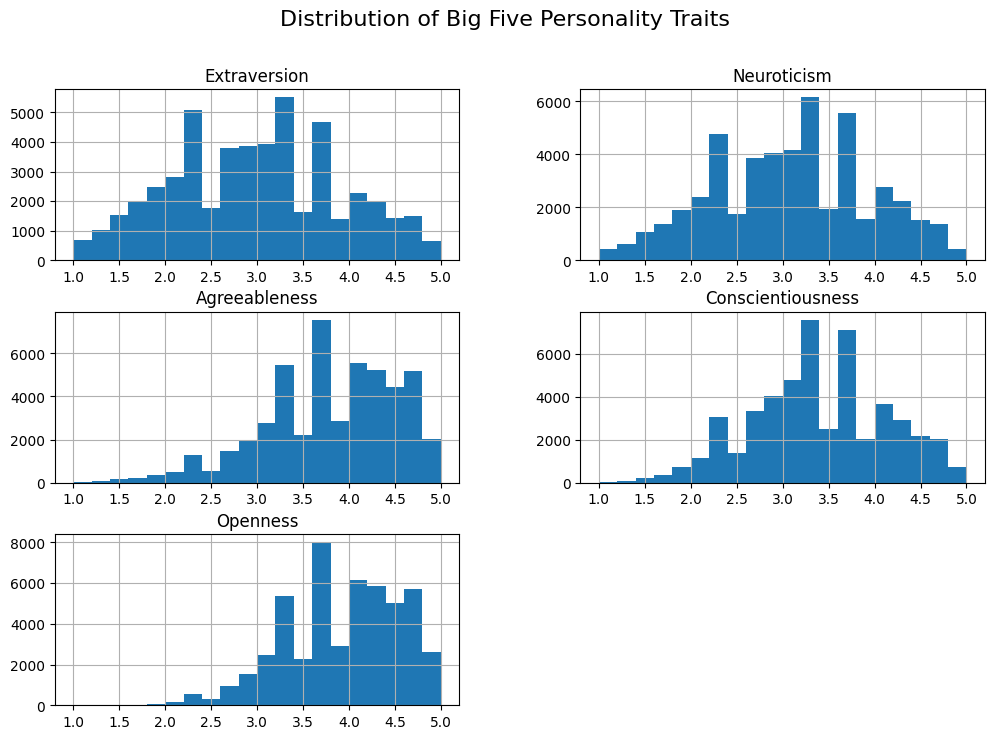

In [93]:
bigfive.hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribution of Big Five Personality Traits", fontsize=16)
plt.show()

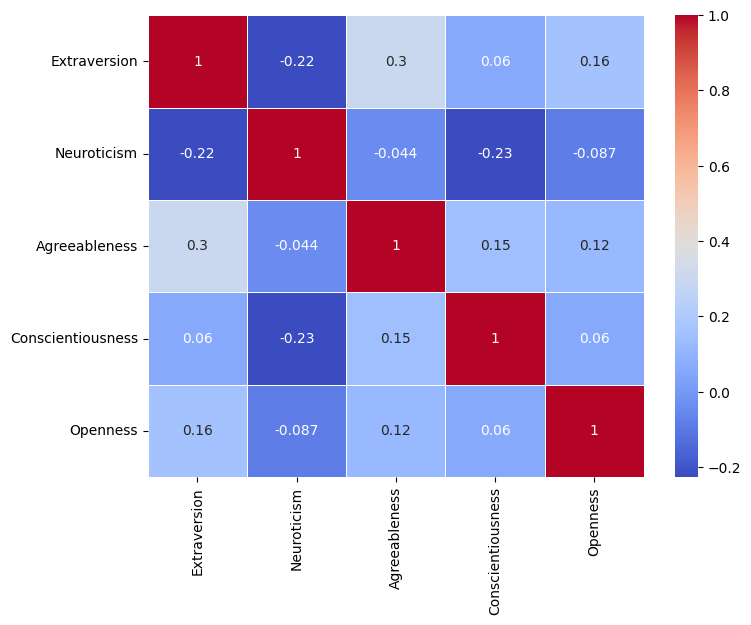

In [94]:
plt.figure(figsize=(8, 6))
sns.heatmap(bigfive.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.show()

## **Data Standardization**

In [95]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bigfive[trait_cols])

## **Find Best Number of Clusters**

This step is used to find the best number of clusters for K-Means.

In [96]:
inertia_values = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia_values.append(kmeans.inertia_)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(5000, X_scaled.shape[0]),
        random_state=42
    )

    silhouette_scores.append(score)

for k, score in zip(k_values, silhouette_scores):
    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.1830
K=3 | Silhouette Score=0.1623
K=4 | Silhouette Score=0.1675
K=5 | Silhouette Score=0.1588
K=6 | Silhouette Score=0.1547
K=7 | Silhouette Score=0.1462
K=8 | Silhouette Score=0.1474
K=9 | Silhouette Score=0.1450
K=10 | Silhouette Score=0.1444


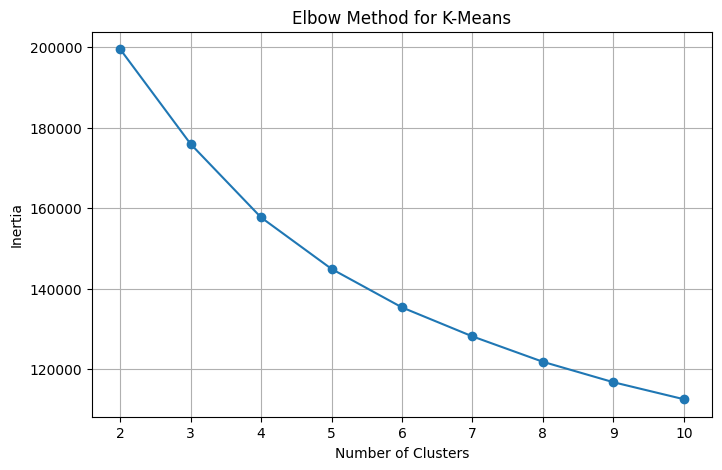

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia_values, marker="o")

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

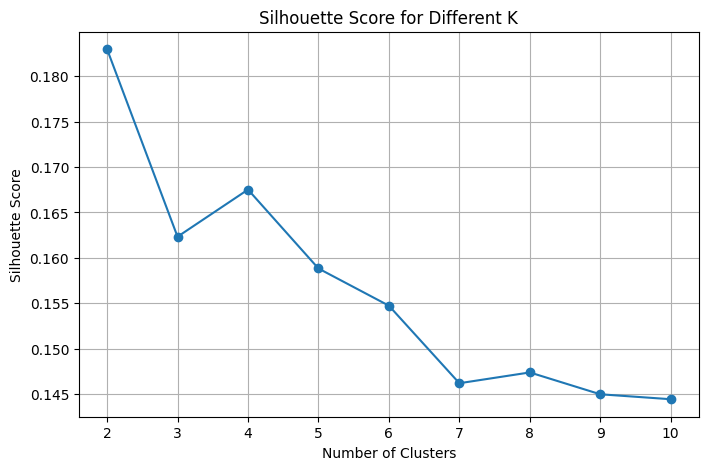

In [98]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# **Model Training**

## K-Means

**Creating & Training K-Means Model**

In [99]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_clusters = kmeans.fit_predict(X_scaled)

bigfive["KMeans_Cluster"] = kmeans_clusters

bigfive.head()

,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness,KMeans_Cluster
132650,3.6,3.6,4.6,3.8,3.6,2
431359,1.7,2.8,3.7,4.0,3.6,3
697542,4.1,3.5,3.5,3.7,3.5,3
542607,2.2,3.0,2.9,4.9,2.7,3
451773,4.7,3.8,4.3,3.2,4.5,0


**Metrics**

In [100]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_clusters,
    sample_size=min(5000, X_scaled.shape[0]),
    random_state=42
)

kmeans_davies = davies_bouldin_score(X_scaled, kmeans_clusters)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_clusters)

print("K-Means Metrics")
print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Score:", kmeans_davies)
print("Calinski-Harabasz Score:", kmeans_calinski)

K-Means Metrics
Silhouette Score: 0.16751851823038613
Davies-Bouldin Score: 1.6618806078850146
Calinski-Harabasz Score: 9752.186114436334


**Cluster Analysis**

In [101]:
kmeans_profile = bigfive.groupby("KMeans_Cluster")[trait_cols].mean()

kmeans_profile

,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
KMeans_Cluster,,,,,
0,3.075575,3.684620,4.079395,2.889427,4.221176
1,2.300066,2.955582,2.826793,3.338188,4.174446
2,3.572684,2.395585,4.196343,3.856455,4.109849
3,2.548844,3.329014,3.622718,3.288505,3.143405


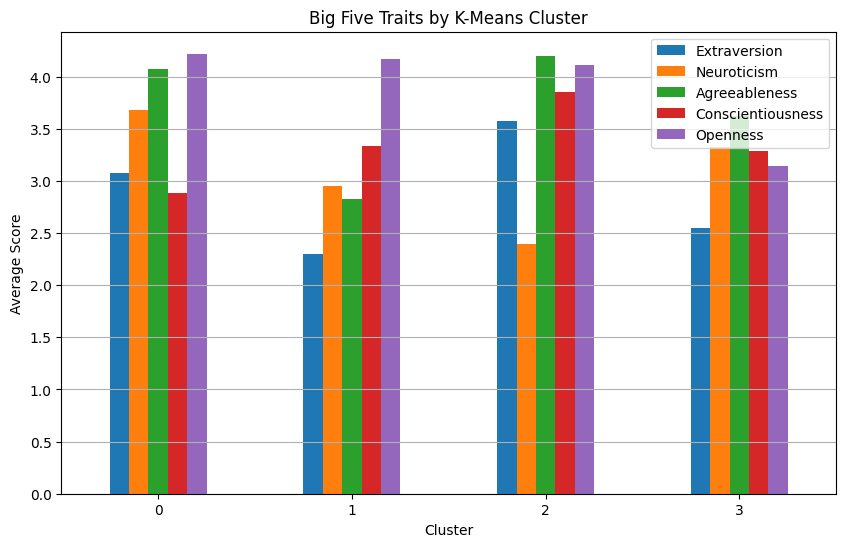

In [102]:
kmeans_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Big Five Traits by K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

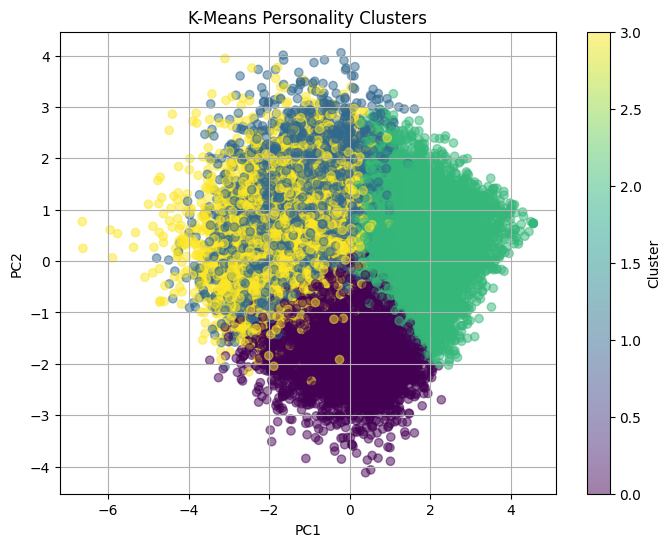

In [103]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_clusters,
    alpha=0.5
)

plt.title("K-Means Personality Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

## DBSCAN

**Creating & Training DBSCAN Model**

In [104]:
dbscan = DBSCAN(eps=0.78, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_scaled)

bigfive["DBSCAN_Cluster"] = dbscan_clusters

print("DBSCAN Cluster Counts:")
print(pd.Series(dbscan_clusters).value_counts().sort_index())

DBSCAN Cluster Counts:
-1      656
 0    49331
 1        4
 2        5
 3        4
Name: count, dtype: int64


**Metrics**

In [105]:
dbscan_mask = dbscan_clusters != -1

if len(set(dbscan_clusters[dbscan_mask])) > 1:

    dbscan_silhouette = silhouette_score(
        X_scaled[dbscan_mask],
        dbscan_clusters[dbscan_mask],
        sample_size=min(5000, dbscan_mask.sum()),
        random_state=42
    )

    dbscan_davies = davies_bouldin_score(
        X_scaled[dbscan_mask],
        dbscan_clusters[dbscan_mask]
    )

    dbscan_calinski = calinski_harabasz_score(
        X_scaled[dbscan_mask],
        dbscan_clusters[dbscan_mask]
    )

else:
    dbscan_silhouette = np.nan
    dbscan_davies = np.nan
    dbscan_calinski = np.nan

print("DBSCAN Metrics")
print("Silhouette Score:", dbscan_silhouette)
print("Davies-Bouldin Score:", dbscan_davies)
print("Calinski-Harabasz Score:", dbscan_calinski)

DBSCAN Metrics
Silhouette Score: 0.20972507547686406
Davies-Bouldin Score: 0.6329949778815703
Calinski-Harabasz Score: 15.136455113504907


**Cluster Analysis**

In [119]:
dbscan_counts = bigfive["DBSCAN_Cluster"].value_counts().sort_index()
dbscan_percent = bigfive["DBSCAN_Cluster"].value_counts(normalize=True).sort_index() * 100

dbscan_summary = pd.DataFrame({
    "Count": dbscan_counts,
    "Percent": dbscan_percent
})

dbscan_summary

,Count,Percent
DBSCAN_Cluster,,
-1,656,1.312
0,49331,98.662
1,4,0.008
2,5,0.010
3,4,0.008


In [106]:
dbscan_profile = bigfive.groupby("DBSCAN_Cluster")[trait_cols].mean()

dbscan_profile

,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
DBSCAN_Cluster,,,,,
-1,2.843902,3.040091,2.627439,2.966159,3.088262
0,2.957228,3.065563,3.788614,3.374762,3.919906
1,1.825000,3.275000,2.725000,1.750000,1.700000
2,3.840000,2.780000,1.440000,4.820000,4.100000
3,3.700000,2.200000,1.375000,2.300000,4.100000


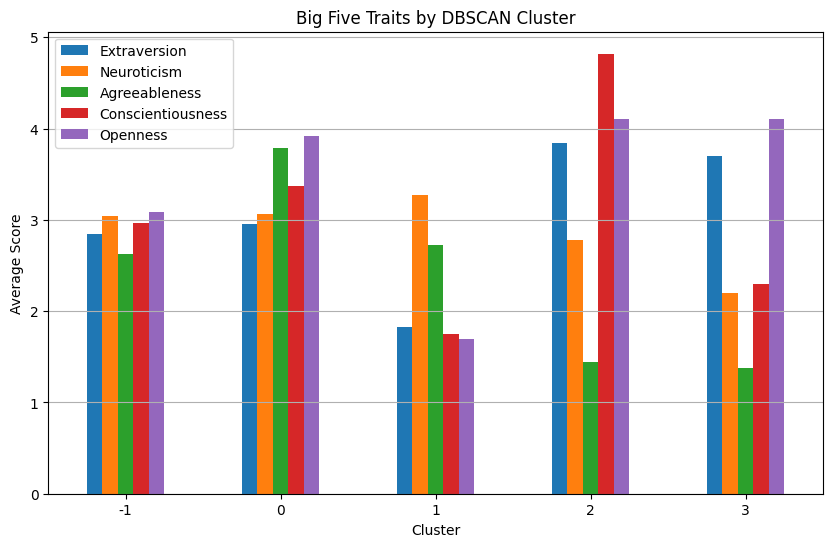

In [107]:
dbscan_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Big Five Traits by DBSCAN Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

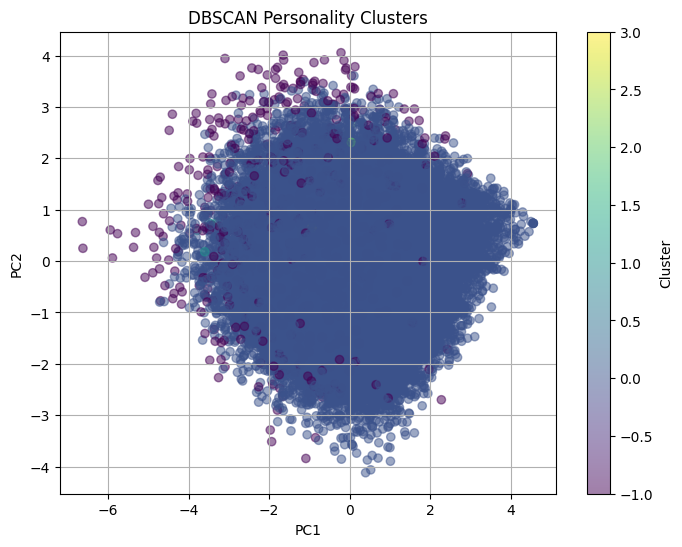

In [108]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_clusters,
    alpha=0.5
)

plt.title("DBSCAN Personality Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

## Mean-Shift

**Creating & Training Mwan-Shift Model**

In [109]:
bandwidth = estimate_bandwidth(
    X_scaled,
    quantile=0.05,
    n_samples=3000,
    random_state=42
)

meanshift = MeanShift(
    bandwidth=bandwidth,
    bin_seeding=True
)

meanshift_clusters = meanshift.fit_predict(X_scaled)

bigfive["MeanShift_Cluster"] = meanshift_clusters

print("Mean-Shift Cluster Counts:")
print(bigfive["MeanShift_Cluster"].value_counts().sort_index())

Mean-Shift Cluster Counts:
MeanShift_Cluster
0    49482
1      365
2      153
Name: count, dtype: int64


**Metrics**

In [110]:
if len(set(meanshift_clusters)) > 1:
    meanshift_silhouette = silhouette_score(
        X_scaled,
        meanshift_clusters,
        sample_size=5000,
        random_state=42
    )

    meanshift_davies = davies_bouldin_score(X_scaled, meanshift_clusters)
    meanshift_calinski = calinski_harabasz_score(X_scaled, meanshift_clusters)

else:
    meanshift_silhouette = np.nan
    meanshift_davies = np.nan
    meanshift_calinski = np.nan

print("Silhouette Score:", meanshift_silhouette)
print("Davies-Bouldin Score:", meanshift_davies)
print("Calinski-Harabasz Score:", meanshift_calinski)

Silhouette Score: 0.2617696059957076
Davies-Bouldin Score: 1.4357076579161874
Calinski-Harabasz Score: 634.7185508272285


**Cluster Analysis**

In [111]:
meanshift_counts = bigfive["MeanShift_Cluster"].value_counts().sort_index()
meanshift_percent = bigfive["MeanShift_Cluster"].value_counts(normalize=True).sort_index() * 100

meanshift_summary = pd.DataFrame({
    "Count": meanshift_counts,
    "Percent": meanshift_percent
})

meanshift_summary

,Count,Percent
MeanShift_Cluster,,
0,49482,98.964
1,365,0.730
2,153,0.306


In [112]:
meanshift_profile = bigfive.groupby("MeanShift_Cluster")[trait_cols].mean()
meanshift_profile

,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
MeanShift_Cluster,,,,,
0,2.960133,3.061600,3.783143,3.381789,3.924381
1,2.647397,3.845205,2.353151,2.172603,2.431507
2,2.289542,2.351634,3.835948,2.194771,2.410458


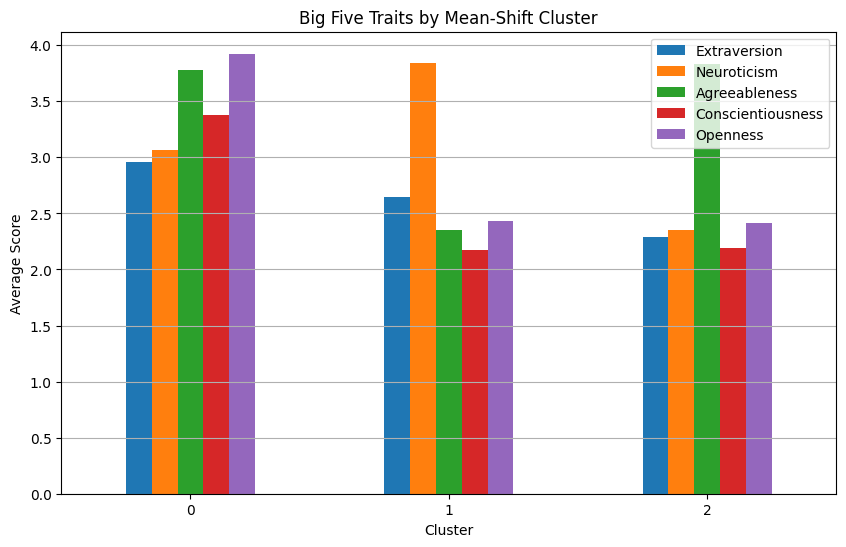

In [113]:
meanshift_profile.plot(kind="bar", figsize=(10, 6))

plt.title("Big Five Traits by Mean-Shift Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

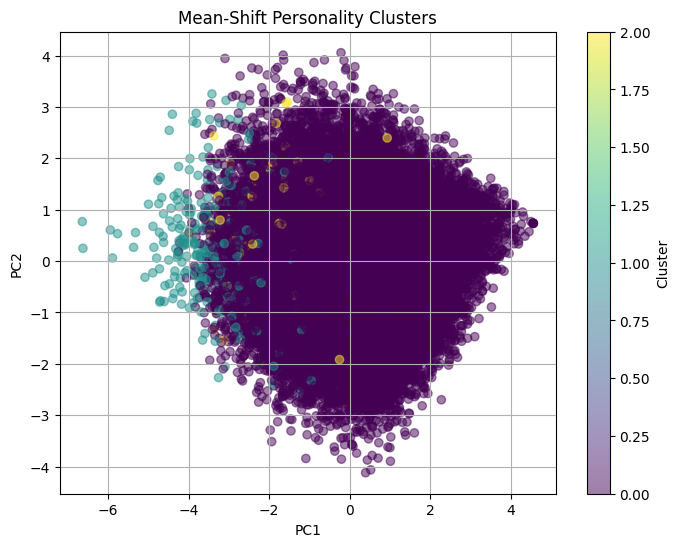

In [114]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=meanshift_clusters,
    alpha=0.5
)

plt.title("Mean-Shift Personality Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

# **Plotting Results**

In [115]:
comparison = pd.DataFrame({
    "Model": ["K-Means", "DBSCAN", "Mean-Shift"],

    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette,
        meanshift_silhouette
    ],

    "Davies-Bouldin Score": [
        kmeans_davies,
        dbscan_davies,
        meanshift_davies
    ],

    "Calinski-Harabasz Score": [
        kmeans_calinski,
        dbscan_calinski,
        meanshift_calinski
    ],

    "Number of Clusters": [
        len(set(kmeans_clusters)),
        len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0),
        len(set(meanshift_clusters))
    ]
})

comparison

,Model,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score,Number of Clusters
0,K-Means,0.167519,1.661881,9752.186114,4
1,DBSCAN,0.209725,0.632995,15.136455,4
2,Mean-Shift,0.261770,1.435708,634.718551,3


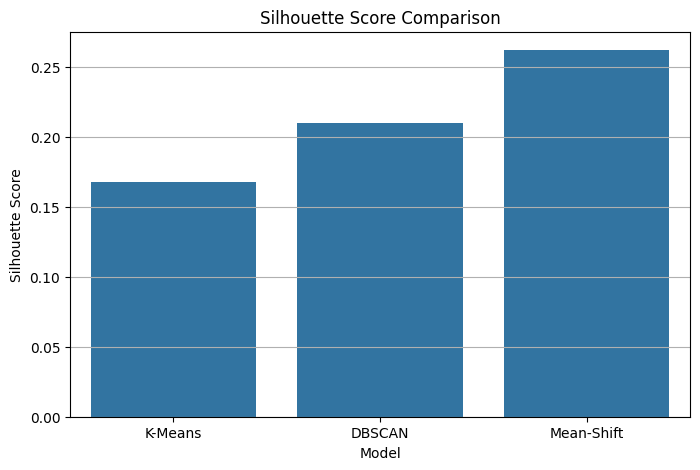

In [116]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Silhouette Score"
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.grid(axis="y")
plt.show()

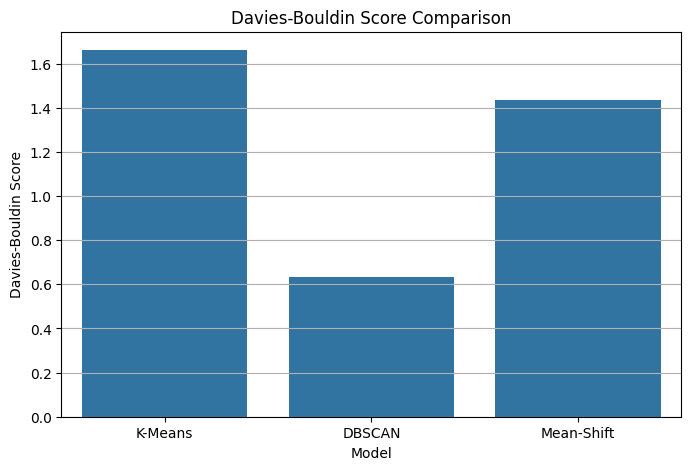

In [117]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Davies-Bouldin Score"
)

plt.title("Davies-Bouldin Score Comparison")
plt.xlabel("Model")
plt.ylabel("Davies-Bouldin Score")
plt.grid(axis="y")
plt.show()

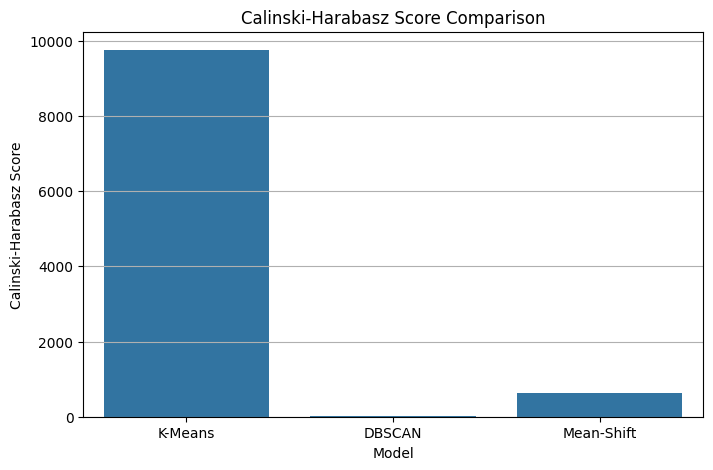

In [118]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Calinski-Harabasz Score"
)

plt.title("Calinski-Harabasz Score Comparison")
plt.xlabel("Model")
plt.ylabel("Calinski-Harabasz Score")
plt.grid(axis="y")
plt.show()

# **Conclusion: Best Algorithm is ...**

In this project, K-Means, DBSCAN, and Mean-Shift were applied to cluster participants based on their Big Five personality traits.

The results showed that K-Means was the most suitable algorithm because it created more balanced and interpretable personality groups. DBSCAN and Mean-Shift were less effective, as they mostly placed the data into one dominant cluster or produced very small clusters.

Therefore, K-Means was selected as the best clustering algorithm for this dataset.